# MZI Fabrication Tolerance -- Critical-Dimension-Bias Sweep (SAX, Component-Composed)

## 1. Introduction

`notebooks/07_mzi.ipynb` designed and validated the passive MZI at exactly
its nominal geometry (`wg_width_um=0.5`, `gap_um=0.2`, `coupling_length_um`
tuned for 50:50 splitting at that exact gap, `delta_L_um=12.5` selected for
maximum in-band extinction) and saved it as this toolkit's single production
MZI design point (`data/design_points/mzi.yaml`). A real fabrication run
never reproduces a design's nominal dimensions exactly -- lithography and
etch introduce a **critical-dimension (CD) bias**, the standard
semiconductor-processing term for a uniform over/under-exposure or
over/under-etch that shifts every drawn feature's size by the same signed
amount. This notebook asks: **how much does this already-selected design's
performance change under a realistic +-10nm critical-dimension bias**,
without re-optimizing anything for the as-built geometry.

**Departure from this folder's usual meep-free rule.** `wdm_sax.ipynb` and
`wdm_mux4_sax.ipynb` only ever wire together *already-cached* component
S-parameters and never import Meep. This notebook is the one exception: a
fabrication-tolerance sweep needs S-parameters at *perturbed* geometries
that were never separately cached, so it deliberately imports
`pic_toolkit.meep_sim.coupler` and `pic_toolkit.meep_sim.mzi` and runs fresh
FDTD both for its own resolution-matched copy of the nominal design
(Section 2) and at each swept point (Section 4, cheap coupler-only runs).
Nothing here writes a new `data/design_points/` entry; the shared nominal
design point itself is unchanged.

**Critical-dimension-bias modeling assumption:** waveguide width and
coupler gap are **not independent** manufacturing variables. A single
critical-dimension bias from one lithography/etch run changes every drawn
feature's width by the same signed amount -- an over-exposed/over-etched
run makes every waveguide wider, which simultaneously narrows every gap
between adjacent waveguides by that same amount (each of the two facing
edges encroaches inward). The physically correct free parameter is one
scalar bias `b`, uniform over +-10nm:
- `wg_width_um = nominal + b`
- `gap_um = nominal - b`

Since `wg_width_um` and `gap_um` move together through `b`, this tolerance
window is one-dimensional -- a random/Monte-Carlo sample buys nothing over
evenly covering it. This sweeps `b` in 5nm steps across the full +-10nm
window (`-10, -5, 0, +5, +10 nm`, 5 points). `coupling_length_um` (tuned
for exactly 50:50 splitting at the nominal gap) and `delta_L_um=12.5` (the
selected interference design point) are held **fixed** at their
already-validated values throughout.

**Component-composed evaluation via `sax.circuit()`, instead of a full
4-port MZI FDTD run per point.** A full `mzi.simulate_baseline()` run costs
on the order of two hours in this environment. `gap_um` only ever enters
the two coupler stages' own geometry -- the delay arm's geometry never
depends on it -- so each swept point's MZI response is instead
reconstructed, the same way `wdm_sax.ipynb` composes its own real-FDTD
circuit, from two much cheaper pieces wired together with `sax.circuit()`:
1. The standalone directional coupler's own fresh FDTD S-parameters
   (`meep_sim/coupler.py`, a far shorter simulation domain than the full
   MZI -- minutes, not hours) at the swept `(wg_width_um, gap_um)`.
2. The delay arm's effective index `n_eff(wavelength)` from a cheap MPB
   eigenmode solve (`meep_sim.mzi.compute_arm_dispersion` -- no FDTD
   timestepping at all) at the swept `wg_width_um`, turned into a 2-port
   phase-delay SAX model (the same role `models/waveguide.py::waveguide()`
   plays for `wdm_sax.ipynb`'s own reference arm).

**Calibration caveat.** A straight-waveguide MPB solve does not capture the
delay arm's own bend-induced effective-index shift (the arm is a tight
raised-cosine bump, not a straight waveguide), and because `delta_L_um` is
large compared to the wavelength, the interference phase
`2*pi*n_eff*delta_L_um/wavelength` is extremely sensitive to `n_eff`.
Section 3 therefore calibrates a small correction to `n_eff` (a constant
offset plus a linear term in wavelength -- i.e. correcting both the local
phase index and the group index/FSR) **once**, against this notebook's own
resolution=50 copy of the nominal design's full-MZI FDTD result (Section 2)
-- kept deliberately separate from the shared, resolution=40
`data/sparams/mzi/selected/mzi_selected` artifact `07_mzi.ipynb` and other
notebooks depend on, so that every comparison in this notebook (nominal vs.
calibration, nominal vs. swept points) is made at one consistent
resolution instead of leaving a resolution mismatch baked into the
comparison. The fitted correction is reused unchanged for every swept point
in Section 4. **This same class of correction is currently missing from
`models/waveguide.py`'s reference-arm model that `wdm_sax.ipynb`/
`wdm_mux4_sax.ipynb` both use** at the time this study was set up; that
shared model has since been given an MPB-measured group-index correction
(see `models/waveguide.py`). This notebook keeps its own calibrated arm
model so its result stays self-contained.

**Method, in order:**
1. Load this notebook's own resolution=50 copy of the nominal design's
   full-MZI FDTD result, running it fresh (once) if not already cached
   (Section 2).
2. Calibrate the arm-phase correction against that nominal result
   (Section 3).
3. Sweep the critical-dimension bias `b` in 5nm steps, running only the
   standalone coupler plus the cheap arm-dispersion solve at each point,
   and compose the MZI response with `sax.circuit()` (Section 4).
4. Report the resulting change in extinction ratio, FSR, and through/cross
   power against the nominal design (Section 5).

**Do not use "Run All."** Sections 2, 3 and 4 each run real FDTD
simulations -- inspect their outputs before continuing.

## 2. User parameters

Loads the MZI's selected design point (`data/design_points/mzi.yaml`) and
the coupler's own design point (`data/design_points/coupler.yaml`, cross-
checked against the MZI's coupler-related parameters), plus this
notebook's tolerance-window setting (`BIAS_TOL_UM`).

The nominal reference for this notebook is its own resolution=50 copy of
the full-MZI FDTD result (loaded if already cached, otherwise simulated
fresh here) -- serving both as Section 3's calibration target and as the
reference every later plot compares against.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sax
from scipy.optimize import minimize

from pic_toolkit.circuits import mzi_lattice as ml
from pic_toolkit.meep_sim import mzi
from pic_toolkit.meep_sim import coupler as coupler_sim
from pic_toolkit import design_points, sweep as sweep_mod, style

style.apply_style()  # shared color palette + plot style for every notebook in this toolkit
%matplotlib inline

# This notebook deliberately imports meep (via meep_sim.mzi/meep_sim.coupler) --
# see Section 1's "departure from this folder's usual meep-free rule".
assert "meep" in sys.modules, "expected meep_sim imports above to pull in meep"


def interp_real(x, xp, fp):
    """np.interp, but sorts xp first -- every wavelengths_um array in this
    toolkit is wavelengths_um=1/freqs with freqs saved increasing, i.e.
    wavelengths_um is itself DESCENDING. Plain np.interp silently assumes xp
    is ascending and gives a wrong (not an error) answer on descending input
    -- enough to quietly corrupt a single-point power readout by a few
    percent.
    Used for every REAL-valued interpolation below; interp_complex (Section
    3) already sorts internally for complex arrays."""
    order = np.argsort(xp)
    return np.interp(x, xp[order], fp[order])


# ============================================================
# USER PARAMETERS
# ============================================================
# Run at the actual SELECTED design point (delta_L_um=12.5), not mzi.py's raw
# DEFAULT_PARAMS (delta_L_um=10.0) -- data/design_points/mzi.yaml is the single
# source of truth for what 07_mzi.ipynb actually chose and validated.
design_point = design_points.load_design_point("../data/design_points/mzi.yaml")
params = {**mzi.DEFAULT_PARAMS, **design_point["parameters"]}

# coupler.py's own design point should agree exactly with the coupler-related
# entries mzi.py's design point carries (07_mzi.ipynb's own Section 2 makes the
# same cross-check) -- confirms the two notebooks haven't drifted apart.
coupler_design_point = design_points.load_design_point("../data/design_points/coupler.yaml")
coupler_params = {**coupler_sim.DEFAULT_PARAMS, **coupler_design_point["parameters"]}
assert coupler_params["gap_um"] == params["gap_um"]
assert coupler_params["wg_width_um"] == params["wg_width_um"]

BIAS_TOL_UM = 0.010  # +-10nm critical-dimension bias, full uniform range (see Section 1)

params

/home/yuma/miniconda3/envs/mp/lib/python3.10/site-packages/sax/backends/__init__.py:78: UserWarning: klujax not found. Please install klujax for better performance during circuit evaluation!
  warnings.warn(


{'coupling_length_um': 13.708639452498595,
 'gap_um': 0.2,
 'wg_width_um': 0.5,
 'wg_height_um': 0.22,
 'core_index': 2.7,
 'clad_index': 1.44,
 'sbend_len_um': 6.0,
 'wide_sep_um': 2.0,
 'lead_len_um': 2.0,
 'n_seg': 24,
 'mon_size_um': 1.2,
 'margin_um': 0.7,
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'n_freq': 101,
 'resolution': 40,
 'dpml_um': 1.0,
 'bump_n_seg': 200,
 'delay_region_len_um': 50.0,
 'delta_L_um': 12.5,
 'dft_decay_tol': 0.001,
 'min_sim_time_factor': 2.0,
 'max_sim_time_factor': 4.0}

> **STOP -- the cell below may run a real full-MZI FDTD simulation (on the order of two hours) the first time.** If `data/sparams/mzi/tolerance/mzi_nominal_res50` is already on disk from an earlier run of this notebook, it is reloaded directly instead -- check before assuming this will be a long wait.

In [2]:
# This notebook's nominal reference must be at the SAME resolution as the
# coupler-FDTD sweep below (RESOLUTION_FOR_SWEEP=50, chosen from a
# resolution-convergence study of the coupler) -- reusing 07_mzi.ipynb's own
# resolution=40 selected artifact here would leave a resolution mismatch baked
# into every "nominal vs. swept point" comparison below. This notebook
# therefore keeps its OWN cached resolution=50 nominal artifact, deliberately
# separate from data/design_points/mzi.yaml's shared resolution=40 design
# point -- 07_mzi.ipynb and every other consumer of that shared artifact are
# untouched.
RESOLUTION_FOR_SWEEP = 50

NOMINAL_RES50_STEM = Path("../data/sparams/mzi/tolerance/mzi_nominal_res50")
if NOMINAL_RES50_STEM.with_suffix(".json").exists():
    print("Loading cached resolution=50 nominal MZI artifact ...", flush=True)
    nominal = mzi.load_artifact(NOMINAL_RES50_STEM)
else:
    print("No cached resolution=50 nominal MZI artifact found -- running a fresh "
          "full-MZI FDTD simulation (the one expensive, hours-scale step in this "
          "notebook) ...", flush=True)
    nominal_result = mzi.simulate_baseline(dict(params, resolution=RESOLUTION_FOR_SWEEP))
    nominal_validation = mzi.run_all_checks(nominal_result)
    assert nominal_validation["passed"], "Fresh nominal MZI simulation failed its own sanity checks -- do not cache it."
    mzi.save_artifact(NOMINAL_RES50_STEM, nominal_result, {
        "component": "mzi",
        "geometry_params": {k: nominal_result.sim_params[k] for k in [
            "coupling_length_um", "gap_um", "wg_width_um", "wg_height_um", "sbend_len_um",
            "wide_sep_um", "lead_len_um", "n_seg", "mon_size_um", "bump_n_seg",
            "delay_region_len_um", "delta_L_um",
        ]},
        "material_params": {k: nominal_result.sim_params[k] for k in ["core_index", "clad_index"]},
        "meep_resolution": RESOLUTION_FOR_SWEEP,
        "meep_version": nominal_result.sim_params["meep_version"],
        "creation_date": nominal_result.sim_params["creation_date"],
        "validation": nominal_validation,
        "rationale": (
            "This notebook's own resolution=50 copy of the nominal design's full-MZI "
            "FDTD result, matching the resolution used for every swept coupler point "
            "below. Deliberately kept separate "
            "from data/sparams/mzi/selected/mzi_selected (resolution=40), which "
            "07_mzi.ipynb and other notebooks still depend on unchanged."
        ),
    })
    nominal = mzi.load_artifact(NOMINAL_RES50_STEM)

WL0_UM = (params["wl_min_um"] + params["wl_max_um"]) / 2  # band-center reference wavelength, same convention as 07_mzi.ipynb
wl_grid = nominal.wavelengths_um  # canonical grid for every composed result in this notebook

assert nominal.metadata["geometry_params"]["gap_um"] == params["gap_um"]
assert nominal.metadata["geometry_params"]["wg_width_um"] == params["wg_width_um"]
assert nominal.metadata["geometry_params"]["delta_L_um"] == params["delta_L_um"]
assert nominal.metadata["meep_resolution"] == RESOLUTION_FOR_SWEEP
print(f"Nominal design point: wg_width_um={params['wg_width_um']}, gap_um={params['gap_um']}, "
      f"delta_L_um={params['delta_L_um']}, resolution={nominal.metadata['meep_resolution']}")

Loading cached resolution=50 nominal MZI artifact ...


Nominal design point: wg_width_um=0.5, gap_um=0.2, delta_L_um=12.5, resolution=50


In [3]:
# Copied verbatim from notebooks/07_mzi.ipynb's own Section 10 (not promoted
# into mzi.py -- same convention 03b_mzi_arm_dense_sweep.ipynb/
# 06b_directional_coupler_gap_sweep.ipynb already follow for a notebook-local
# helper).
def _local_maxima_indices(y, min_prominence_fraction=0.1):
    """Local-maximum indices (interior points only), keeping only peaks whose
    PROMINENCE (height above the adjacent valleys) exceeds `min_prominence_fraction`
    of the spectrum's own dynamic range -- filters out FDTD numerical noise so a
    single broad fringe isn't miscounted as two."""
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(y, prominence=min_prominence_fraction * (np.max(y) - np.min(y)))
    return peaks


def fringe_metrics(wavelengths_um, power, wl0_um):
    """FSR = mean spacing between successive fringe maxima (NaN if fewer than 2
    are found -- FSR exceeds the analyzed band). extinction_db = 10*log10 of the
    spectrum's max/min power ratio. peak_near_center_um = the detected fringe
    closest to the band-center wavelength wl0_um."""
    peaks = _local_maxima_indices(power)
    if len(peaks) >= 2:
        fsr_um = float(np.mean(np.diff(np.sort(wavelengths_um[peaks]))))
    else:
        fsr_um = float("nan")
    extinction_db = float(10 * np.log10(np.max(power) / max(np.min(power), 1e-12)))
    if len(peaks) >= 1:
        peak_wls = wavelengths_um[peaks]
        peak_near_center_um = float(peak_wls[np.argmin(np.abs(peak_wls - wl0_um))])
    else:
        peak_near_center_um = float("nan")
    return dict(fsr_um=fsr_um, extinction_db=extinction_db, peak_near_center_um=peak_near_center_um,
                n_peaks=int(len(peaks)))


nominal_fringe = fringe_metrics(nominal.wavelengths_um, np.abs(nominal.S41) ** 2, WL0_UM)
nominal_fringe

{'fsr_um': 0.051100179709308025,
 'extinction_db': 35.40523493009689,
 'peak_near_center_um': 1.3631446087270105,
 'n_peaks': 2}

## 3. Calibrating the arm-phase correction against the nominal design

Runs the standalone coupler once at the nominal geometry (at
`RESOLUTION_FOR_SWEEP`) and solves the arm's straight-waveguide
`n_eff(wavelength)` once (MPB, no FDTD), then fits a correction
`n_eff_corrected(wavelength) = n_eff(wavelength) + a + b*(wavelength -
WL0_UM)` so that composing these two pieces reproduces the nominal
design's own full-MZI FDTD spectrum (Section 2) as closely as possible.
`a` corrects the arm's local phase index; `b` corrects its group index
(equivalently, the reconstructed FSR) -- both are needed because the delay
arm's bend shifts both, not just one. This is the only step in this
notebook that reads a full-MZI result; the fitted `(a, b)` is then reused
unchanged for every point in Section 4. The fit itself is a plain numeric
optimization (not yet a `sax.circuit()`); Section 4's actual sweep wires
the calibrated result through `sax.circuit()`, and the cell after next
double-checks the two give the same answer.

In [4]:
def interp_complex(wl_target, wl_src, y_src):
    order = np.argsort(wl_src)
    re = np.interp(wl_target, wl_src[order], y_src.real[order])
    im = np.interp(wl_target, wl_src[order], y_src.imag[order])
    return re + 1j * im


def compose_mzi_response(S_through, S_cross, wavelengths_um, n_eff, L_top, L_bot):
    """Cascade two identical coupler stages (given by their complex
    S_through/S_cross, assumed top/bottom symmetric) with an intervening
    pair of arm phase delays into the full MZI's S31 (through) and S41
    (cross) response -- M(wavelength) = C * P * C, see Section 1. Plain
    numpy, used only for the fast calibration search below; the actual
    sweep in Section 4 wires the equivalent computation through
    sax.circuit() instead (see the sanity-check cell right after this one)."""
    phi_top = 2 * np.pi * n_eff * L_top / wavelengths_um
    phi_bot = 2 * np.pi * n_eff * L_bot / wavelengths_um
    S31 = np.empty(len(wavelengths_um), dtype=complex)
    S41 = np.empty(len(wavelengths_um), dtype=complex)
    for i in range(len(wavelengths_um)):
        C = np.array([[S_through[i], S_cross[i]], [S_cross[i], S_through[i]]])
        P = np.diag([np.exp(1j * phi_top[i]), np.exp(1j * phi_bot[i])])
        M = C @ P @ C
        S31[i] = M[0, 0]
        S41[i] = M[1, 0]
    return S31, S41


# Cached the same way as Section 2's nominal full-MZI result -- lets this
# cell (and the relocated comparison plot in wdm_sax.ipynb, which needs this
# exact data without importing meep) skip re-simulating on every run.
COUPLER_NOMINAL_STEM = Path("../data/sparams/coupler/tolerance/coupler_nominal_res50")
if COUPLER_NOMINAL_STEM.with_suffix(".json").exists():
    print("Loading cached resolution=50 nominal coupler artifact ...", flush=True)
    coupler_nominal = coupler_sim.load_artifact(COUPLER_NOMINAL_STEM)
else:
    print("[calibration] running standalone coupler at nominal geometry ...", flush=True)
    coupler_nominal_result = coupler_sim.simulate_baseline(dict(coupler_params, resolution=RESOLUTION_FOR_SWEEP))
    coupler_nominal_validation = coupler_sim.run_all_checks(coupler_nominal_result)
    assert coupler_nominal_validation["passed"], "Nominal coupler failed its own sanity checks -- do not calibrate on it."
    coupler_sim.save_artifact(COUPLER_NOMINAL_STEM, coupler_nominal_result, {
        "component": "coupler", "study": "fabrication_tolerance_calibration",
        "geometry_params": {k: coupler_nominal_result.sim_params[k] for k in [
            "coupling_length_um", "gap_um", "wg_width_um", "wg_height_um", "sbend_len_um", "wide_sep_um",
        ]},
        "material_params": {k: coupler_nominal_result.sim_params[k] for k in ["core_index", "clad_index"]},
        "meep_resolution": RESOLUTION_FOR_SWEEP,
        "meep_version": coupler_nominal_result.sim_params["meep_version"],
        "creation_date": coupler_nominal_result.sim_params["creation_date"],
        "validation": coupler_nominal_validation,
    })
    coupler_nominal = coupler_sim.load_artifact(COUPLER_NOMINAL_STEM)

S_through_nom = interp_complex(wl_grid, coupler_nominal.wavelengths_um, coupler_nominal.S_through)
S_cross_nom = interp_complex(wl_grid, coupler_nominal.wavelengths_um, coupler_nominal.S_cross)

disp_nominal = mzi.compute_arm_dispersion(params, wl_grid)
n_eff0_nom = disp_nominal["n_eff"]

L_top = params["delay_region_len_um"]
L_bot = params["delay_region_len_um"] + params["delta_L_um"]

target31 = np.abs(nominal.S31) ** 2
target41 = np.abs(nominal.S41) ** 2


def calibration_loss(ab):
    a, b = ab
    n_eff = n_eff0_nom + a + b * (wl_grid - WL0_UM)
    S31, S41 = compose_mzi_response(S_through_nom, S_cross_nom, wl_grid, n_eff, L_top, L_bot)
    return float(np.sum((np.abs(S31) ** 2 - target31) ** 2) + np.sum((np.abs(S41) ** 2 - target41) ** 2))


# The interference phase is extremely sensitive to n_eff (see Section 1), so
# a gradient-based fit from an arbitrary start can lock onto the wrong 2*pi
# branch -- coarse-grid first, then refine, same approach as this toolkit's
# other interference/resonance phase fits.
a_grid = np.linspace(-0.05, 0.05, 401)
b_grid = np.linspace(-0.5, 0.5, 41)
best = None
for a in a_grid:
    for b in b_grid:
        loss = calibration_loss((a, b))
        if best is None or loss < best[0]:
            best = (loss, a, b)
print(f"[calibration] coarse grid best: a={best[1]:.5f}, b={best[2]:.5f}, loss={best[0]:.4f}", flush=True)

fit = minimize(calibration_loss, x0=[best[1], best[2]], method="Nelder-Mead",
               options=dict(xatol=1e-6, fatol=1e-8, maxiter=5000))
CALIBRATION_A, CALIBRATION_B = fit.x
print(f"[calibration] refined: a={CALIBRATION_A:.6f}, b={CALIBRATION_B:.6f}, loss={fit.fun:.4f}", flush=True)

Loading cached resolution=50 nominal coupler artifact ...


[calibration] coarse grid best: a=-0.01550, b=0.00000, loss=0.0330


[calibration] refined: a=-0.015568, b=-0.004364, loss=0.0312


**SAX model helpers.** `sax_model_from_coupler_result` wraps a freshly-
simulated `CouplerResult` into the same `{(port_i, port_j): S_ij}` SDict
shape `models/coupler.py::coupler()` returns for the cached nominal design
(reused for every coupler stage below -- both the calibration check and
the real sweep). `make_arm_phase_model` builds a 2-port phase-delay SAX
model from a calibrated `n_eff(wavelength)`, the same role
`models/waveguide.py::waveguide()` plays for `wdm_sax.ipynb`'s reference
arm -- except this one actually carries the fitted dispersion correction.

In [5]:
def sax_model_from_coupler_result(cr):
    """SAX model function for a freshly-simulated 4-port coupler -- same SDict
    shape as models/coupler.py's own _sdict_from_artifact, built from an
    in-memory CouplerResult instead of a cached artifact on disk."""
    wl_src = cr.wavelengths_um
    in_top, in_bot, out_top, out_bot = cr.port_names

    def model(wl=1.35):
        wl = np.asarray(wl, dtype=float)
        s_through = interp_complex(wl, wl_src, cr.S_through)
        s_cross = interp_complex(wl, wl_src, cr.S_cross)
        s_r = interp_complex(wl, wl_src, cr.S_reflect)
        s_through_bot = interp_complex(wl, wl_src, cr.S_through_bot)
        s_cross_bot = interp_complex(wl, wl_src, cr.S_cross_bot)
        s_r_bot = interp_complex(wl, wl_src, cr.S_reflect_bot)
        return {
            (in_top, out_top): s_through, (out_top, in_top): s_through,
            (in_top, out_bot): s_cross, (out_bot, in_top): s_cross,
            (in_top, in_top): s_r,
            (in_bot, out_bot): s_through_bot, (out_bot, in_bot): s_through_bot,
            (in_bot, out_top): s_cross_bot, (out_top, in_bot): s_cross_bot,
            (in_bot, in_bot): s_r_bot,
        }

    return model


def make_arm_phase_model(n_eff_wl_grid, n_eff0, calibration_a, calibration_b, wl0_um, length_um):
    """2-port (o1, o2) phase-delay SAX model using the calibrated
    n_eff(wavelength) -- same role as models/waveguide.py::waveguide(), but
    with the fitted dispersion correction from Section 3 instead of a bare
    constant n_eff."""

    order = np.argsort(n_eff_wl_grid)  # n_eff_wl_grid = 1/freqs is DESCENDING; np.interp requires ascending xp
    n_eff_wl_sorted, n_eff0_sorted = n_eff_wl_grid[order], n_eff0[order]

    def model(wl=1.35):
        wl = np.asarray(wl, dtype=float)
        n_eff_local = np.interp(wl, n_eff_wl_sorted, n_eff0_sorted) + calibration_a + calibration_b * (wl - wl0_um)
        phase = 2 * np.pi * n_eff_local * length_um / wl
        s21 = np.exp(1j * phase)
        zero = np.zeros_like(wl, dtype=complex)
        return {("o1", "o1"): zero, ("o1", "o2"): s21, ("o2", "o1"): s21, ("o2", "o2"): zero}

    return model


def build_mzi_circuit(coupler_model_fn, top_arm_model_fn, delay_arm_model_fn):
    """Same N=2 wiring pattern as wdm_sax.ipynb's own N=2 netlist (coupler1 ->
    {ref_arm, delay_arm} -> coupler2), just with this device's own raised-
    cosine-bump delay arm and straight top arm instead of that notebook's
    mzi_arm/waveguide components."""
    netlist = {
        "instances": {
            "coupler1": {"component": "coupler", "settings": {}},
            "coupler2": {"component": "coupler", "settings": {}},
            "top_arm": {"component": "top_arm", "settings": {}},
            "delay_arm": {"component": "delay_arm", "settings": {}},
        },
        "connections": {
            "coupler1,out_top": "top_arm,o1",
            "coupler1,out_bot": "delay_arm,o1",
            "top_arm,o2": "coupler2,in_top",
            "delay_arm,o2": "coupler2,in_bot",
        },
        "ports": {
            "in_top": "coupler1,in_top", "in_bot": "coupler1,in_bot",
            "out_top": "coupler2,out_top", "out_bot": "coupler2,out_bot",
        },
    }
    models = {
        "coupler": ml.unitary_project(coupler_model_fn, ("in_top", "in_bot", "out_top", "out_bot")),
        "top_arm": top_arm_model_fn,
        "delay_arm": delay_arm_model_fn,
    }
    circuit, _ = sax.circuit(netlist, models=models)
    return circuit

In [6]:
# Sanity check the calibration reproduces the real full-MZI FDTD result it was
# fit against, and save the comparison data so wdm_sax.ipynb's own comparison
# section can plot it without needing to re-run any FDTD (the plot lives there,
# next to the other real-vs-ideal circuit comparisons).
top_arm_nom = make_arm_phase_model(wl_grid, n_eff0_nom, CALIBRATION_A, CALIBRATION_B, WL0_UM, L_top)
delay_arm_nom = make_arm_phase_model(wl_grid, n_eff0_nom, CALIBRATION_A, CALIBRATION_B, WL0_UM, L_bot)
circuit_nom = build_mzi_circuit(sax_model_from_coupler_result(coupler_nominal), top_arm_nom, delay_arm_nom)

S_nom = circuit_nom(wl=wl_grid)
S31_cal, S41_cal = np.asarray(S_nom[("in_top", "out_top")]), np.asarray(S_nom[("in_top", "out_bot")])

mean_abs_err = float(np.mean(np.abs(target41 - np.abs(S41_cal) ** 2)))
print(f"mean |S41|^2 absolute error after calibration: {mean_abs_err:.4f}")
assert mean_abs_err < 0.05, (
    "Calibration fit is not tight enough to trust the composed sweep -- inspect the "
    "comparison plot in wdm_sax.ipynb's Section 5."
)

CALIBRATION_CHECK_STEM = Path("../data/sparams/mzi/tolerance/calibration_check")
np.savez(CALIBRATION_CHECK_STEM.with_suffix(".npz"),
         wl_grid=wl_grid, target31=target31, target41=target41, S31_cal=S31_cal, S41_cal=S41_cal)
CALIBRATION_CHECK_STEM.with_suffix(".json").write_text(json.dumps({
    "component": "mzi", "study": "fabrication_tolerance_calibration_check",
    "resolution": RESOLUTION_FOR_SWEEP,
    "calibration_a": CALIBRATION_A, "calibration_b": CALIBRATION_B,
    "mean_abs_err_S41": mean_abs_err,
    "description": (
        "Comparison of the real nominal full-MZI FDTD spectrum (target31/target41, "
        "this notebook's Section 2, resolution=50) against the coupler-FDTD + "
        "calibrated-arm-phase sax.circuit() reconstruction (S31_cal/S41_cal) this "
        "notebook's Section 3 fits. Plotted in wdm_sax.ipynb's own comparison "
        "section, not here."
    ),
}, indent=2))
print(f"Saved calibration comparison data: {CALIBRATION_CHECK_STEM}")

mean |S41|^2 absolute error after calibration: 0.0078
Saved calibration comparison data: ../data/sparams/mzi/tolerance/calibration_check


## 4. Component-composed critical-dimension-bias sweep

At each swept bias point, runs only the standalone coupler (fast) and the
arm-dispersion solve (near-instant), then builds a fresh `sax.circuit()`
with Section 3's fixed `(CALIBRATION_A, CALIBRATION_B)` correction --
`wg_width_um`/`gap_um` move together, derived from `b`. Each point's
composed result and metadata are saved immediately, so an interrupted run
can be resumed without redoing already-completed points.

> **STOP -- THIS CELL RUNS THE FULL SWEEP.** Each point is one standalone
> coupler FDTD run (minutes); confirm Section 3's calibration check passed
> its own tolerance before running this.

In [7]:
BIAS_STEP_NM = 5
bias_nm_values = np.arange(-1000 * BIAS_TOL_UM, 1000 * BIAS_TOL_UM + BIAS_STEP_NM, BIAS_STEP_NM)

sample_params = [
    dict(
        index=i,
        bias_nm=float(b_nm),
        wg_width_um=params["wg_width_um"] + b_nm / 1000,
        gap_um=params["gap_um"] - b_nm / 1000,
    )
    for i, b_nm in enumerate(bias_nm_values)
]
N_SAMPLES = len(sample_params)
print(f"{N_SAMPLES} critical-dimension-bias sample points, step={BIAS_STEP_NM}nm: "
      f"{[s['bias_nm'] for s in sample_params]}")

5 critical-dimension-bias sample points, step=5nm: [-10.0, -5.0, 0.0, 5.0, 10.0]


In [8]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.05, reciprocity_tol=0.08, passivity_tol=0.03, max_expected_loss=0.12)
# Same loosened tolerances as 07_mzi.ipynb's own Section 10 delta_L sweep --
# validates the coupler stage actually driving this sweep's composed result.

TOLERANCE_DIR = Path("../data/sparams/mzi/tolerance")
TOLERANCE_DIR.mkdir(parents=True, exist_ok=True)


def save_composed_artifact(stem, wavelengths_um, S31, S41, metadata):
    """This notebook's own artifact format for a COMPOSED (coupler + calibrated
    arm phase, via sax.circuit()) result -- deliberately distinct from
    mzi.save_artifact's format (which holds a genuine full-device FDTD result
    with all 8 S-parameters): conflating the two would let a composed
    approximation be mistaken for a directly-simulated MZI result later."""
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    np.savez(stem.with_suffix(".npz"), wavelengths_um=wavelengths_um, S31=S31, S41=S41)
    stem.with_suffix(".json").write_text(json.dumps(metadata, indent=2, default=str))


def load_composed_artifact(stem):
    stem = Path(stem)
    data = np.load(stem.with_suffix(".npz"))
    metadata = json.loads(stem.with_suffix(".json").read_text())
    return data["wavelengths_um"], data["S31"], data["S41"], metadata


def _build_row(index, wg_width_um, gap_um, bias_nm, wavelengths_um, S31, S41, validation_passed, fm):
    return {
        "index": index, "wg_width_um": wg_width_um, "gap_um": gap_um, "bias_nm": bias_nm,
        "validation_passed": validation_passed,
        "power_S31_at_wl0": float(interp_real(WL0_UM, wavelengths_um, np.abs(S31) ** 2)),
        "power_S41_at_wl0": float(interp_real(WL0_UM, wavelengths_um, np.abs(S41) ** 2)),
        **fm,
    }


tolerance_rows = []
for s in sample_params:
    i = s["index"]
    stem = TOLERANCE_DIR / f"mzi_tol{i:03d}"
    meta_path = stem.with_suffix(".json")

    if meta_path.exists():
        # Resume safety: skip points an earlier, interrupted run of this
        # notebook already completed. Only trust the cached file if its
        # bias actually matches this run's sweep point (guards against a
        # stale artifact left over from a differently-configured sweep).
        metadata = json.loads(meta_path.read_text())
        # Trust the cached artifact only if BOTH the bias point AND the calibration
        # it was composed with still match this run's -- a bias-only check would
        # silently reuse a sweep point fit under a stale (a, b), e.g. after Section 2
        # regenerates the nominal at a different resolution and Section 3 re-fits
        # (e.g. after changing the nominal's resolution).
        stale_calibration = (
            metadata.get("calibration_a") != CALIBRATION_A or metadata.get("calibration_b") != CALIBRATION_B
        )
        if metadata.get("bias_nm") == s["bias_nm"] and not stale_calibration:
            print(f"[{i + 1}/{N_SAMPLES}] mzi_tol{i:03d} already on disk, skipping.", flush=True)
            wl_i, S31_i, S41_i, metadata = load_composed_artifact(stem)
            row = _build_row(i, metadata["wg_width_um"], metadata["gap_um"], metadata["bias_nm"],
                              wl_i, S31_i, S41_i, metadata["coupler_validation"]["passed"], metadata["fringe_metrics"])
            tolerance_rows.append(row)
            continue
        if stale_calibration:
            print(f"[{i + 1}/{N_SAMPLES}] mzi_tol{i:03d} on disk but calibration stale "
                  f"(a={metadata.get('calibration_a')}, b={metadata.get('calibration_b')} != "
                  f"current a={CALIBRATION_A}, b={CALIBRATION_B}) -- re-running.", flush=True)
        else:
            print(f"[{i + 1}/{N_SAMPLES}] mzi_tol{i:03d} on disk but bias mismatch "
                  f"({metadata.get('bias_nm')} != {s['bias_nm']}) -- re-running.", flush=True)

    print(f"[{i + 1}/{N_SAMPLES}] running coupler (bias={s['bias_nm']:+.1f}nm, "
          f"wg_width_um={s['wg_width_um']:.4f}, gap_um={s['gap_um']:.4f}) ...", flush=True)
    run_params = dict(coupler_params, resolution=RESOLUTION_FOR_SWEEP,
                       wg_width_um=s["wg_width_um"], gap_um=s["gap_um"])
    cr = coupler_sim.simulate_baseline(run_params)
    cv = coupler_sim.run_all_checks(cr, **SWEEP_CHECK_KWARGS)

    disp_i = mzi.compute_arm_dispersion(dict(params, wg_width_um=s["wg_width_um"]), wl_grid)
    top_arm_i = make_arm_phase_model(wl_grid, disp_i["n_eff"], CALIBRATION_A, CALIBRATION_B, WL0_UM, L_top)
    delay_arm_i = make_arm_phase_model(wl_grid, disp_i["n_eff"], CALIBRATION_A, CALIBRATION_B, WL0_UM, L_bot)
    circuit_i = build_mzi_circuit(sax_model_from_coupler_result(cr), top_arm_i, delay_arm_i)
    S_i = circuit_i(wl=wl_grid)
    S31_i = np.asarray(S_i[("in_top", "out_top")])
    S41_i = np.asarray(S_i[("in_top", "out_bot")])
    fm = fringe_metrics(wl_grid, np.abs(S41_i) ** 2, WL0_UM)

    save_composed_artifact(stem, wl_grid, S31_i, S41_i, {
        "component": "mzi", "study": "fabrication_tolerance", "method": "sax_circuit_coupler_fdtd_plus_calibrated_arm_phase",
        "wg_width_um": s["wg_width_um"], "gap_um": s["gap_um"], "bias_nm": s["bias_nm"],
        "resolution": RESOLUTION_FOR_SWEEP,
        "calibration_a": CALIBRATION_A, "calibration_b": CALIBRATION_B,
        "coupler_validation": cv, "fringe_metrics": fm,
        "meep_version": cr.sim_params["meep_version"], "creation_date": cr.sim_params["creation_date"],
    })
    row = _build_row(i, s["wg_width_um"], s["gap_um"], s["bias_nm"], wl_grid, S31_i, S41_i, cv["passed"], fm)
    tolerance_rows.append(row)

n_passed = sum(row["validation_passed"] for row in tolerance_rows)
print(f"fabrication-tolerance sweep: {n_passed}/{len(tolerance_rows)} points' coupler stage within tolerance")

manifest_path = TOLERANCE_DIR / "manifest.csv"
sweep_mod.save_manifest(tolerance_rows, manifest_path)
print(f"Saved manifest to {manifest_path}")

[1/5] running coupler (bias=-10.0nm, wg_width_um=0.4900, gap_um=0.2100) ...


[2/5] running coupler (bias=-5.0nm, wg_width_um=0.4950, gap_um=0.2050) ...


[3/5] running coupler (bias=+0.0nm, wg_width_um=0.5000, gap_um=0.2000) ...


[4/5] running coupler (bias=+5.0nm, wg_width_um=0.5050, gap_um=0.1950) ...


[5/5] running coupler (bias=+10.0nm, wg_width_um=0.5100, gap_um=0.1900) ...


fabrication-tolerance sweep: 5/5 points' coupler stage within tolerance
Saved manifest to ../data/sparams/mzi/tolerance/manifest.csv


## 5. Summary and response-to-bias plots

Loads every saved point's composed artifact and summarizes extinction
ratio, FSR, and through/cross power at the band-center wavelength across
the swept bias range, against the nominal (unperturbed) values.

In [9]:
passed_rows = [row for row in tolerance_rows if row["validation_passed"]]
print(f"{len(passed_rows)}/{len(tolerance_rows)} points passed validation; "
      "the summary below uses only the passed points.")

# Reload each passed point's composed spectrum once -- reused by both the
# summary table below and the spectral-envelope plot.
loaded_tolerance = {}
for row in passed_rows:
    wl_i, S31_i, S41_i, _ = load_composed_artifact(TOLERANCE_DIR / f"mzi_tol{row['index']:03d}")
    loaded_tolerance[row["index"]] = (wl_i, S31_i, S41_i)

METRICS = ["extinction_db", "fsr_um", "power_S31_at_wl0", "power_S41_at_wl0"]
summary = {}
for m in METRICS:
    vals = np.array([row[m] for row in passed_rows if not np.isnan(row[m])])
    summary[m] = dict(mean=float(np.mean(vals)), std=float(np.std(vals)),
                       min=float(np.min(vals)), max=float(np.max(vals)), n=len(vals))

nominal_power_S31 = float(interp_real(WL0_UM, nominal.wavelengths_um, np.abs(nominal.S31) ** 2))
nominal_power_S41 = float(interp_real(WL0_UM, nominal.wavelengths_um, np.abs(nominal.S41) ** 2))
print(f"nominal: extinction_db={nominal_fringe['extinction_db']:.2f}, fsr_um={nominal_fringe['fsr_um']:.4f}, "
      f"power_S31_at_wl0={nominal_power_S31:.4f}, power_S41_at_wl0={nominal_power_S41:.4f}")
print(json.dumps(summary, indent=2))

5/5 points passed validation; the summary below uses only the passed points.
nominal: extinction_db=35.41, fsr_um=0.0511, power_S31_at_wl0=0.3801, power_S41_at_wl0=0.5757
{
  "extinction_db": {
    "mean": 43.73502044677734,
    "std": 5.7263733709732625,
    "min": 37.35196304321289,
    "max": 54.282649993896484,
    "n": 5
  },
  "fsr_um": {
    "mean": 0.04911591730253839,
    "std": 0.0001865285641350303,
    "min": 0.048845830292731485,
    "max": 0.049350809293126296,
    "n": 4
  },
  "power_S31_at_wl0": {
    "mean": 0.37602035105228426,
    "std": 0.19970308068557144,
    "min": 0.094035804271698,
    "max": 0.6488697528839111,
    "n": 5
  },
  "power_S41_at_wl0": {
    "mean": 0.6239573717117309,
    "std": 0.19968589432695794,
    "min": 0.3511269986629486,
    "max": 0.9058964252471924,
    "n": 5
  }
}


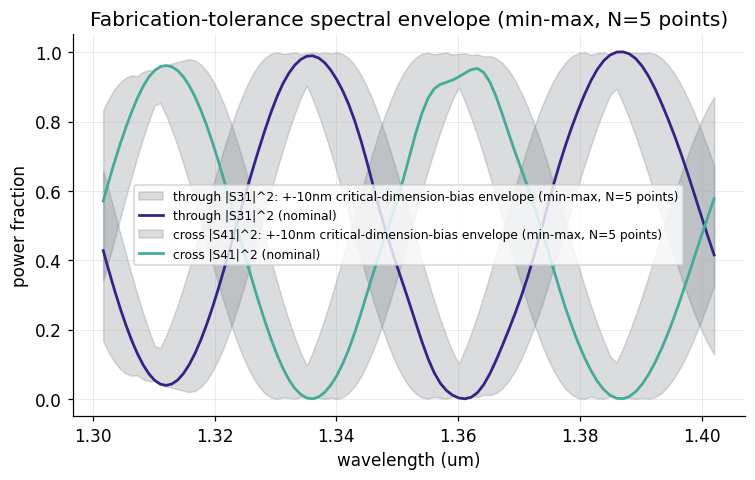

In [10]:
# Interpolate every passed point's spectrum onto the nominal wavelength grid
# so they can be stacked into one min-max envelope across the swept bias
# range (a min-max BAND, not a statistical mean+-std, since these are
# deterministic sweep points, not random draws).
S31_stack = np.array([interp_real(wl_grid, wl_i, np.abs(S31_i) ** 2) for wl_i, S31_i, S41_i in loaded_tolerance.values()])
S41_stack = np.array([interp_real(wl_grid, wl_i, np.abs(S41_i) ** 2) for wl_i, S31_i, S41_i in loaded_tolerance.values()])

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, stack, nominal_curve, color in [
    ("through |S31|^2", S31_stack, np.abs(nominal.S31) ** 2, style.COLOR_CYCLE[0]),
    ("cross |S41|^2", S41_stack, np.abs(nominal.S41) ** 2, style.COLOR_CYCLE[2]),
]:
    # Shaded band = min-max envelope across the swept bias range, extending
    # COLOR_REFERENCE's existing "reference/uncertainty" role to a new
    # envelope-plot use -- this toolkit has no dedicated envelope-plot color
    # convention yet. Labeled explicitly so a reader isn't left guessing what
    # the gray shading means.
    ax.fill_between(wl_grid, stack.min(axis=0), stack.max(axis=0),
                     color=style.COLOR_REFERENCE, alpha=0.25,
                     label=f"{label}: +-10nm critical-dimension-bias envelope (min-max, N={len(passed_rows)} points)")
    ax.plot(wl_grid, nominal_curve, color=color, lw=1.8, label=f"{label} (nominal)")

ax.set_xlabel("wavelength (um)")
ax.set_ylabel("power fraction")
ax.set_title(f"Fabrication-tolerance spectral envelope (min-max, N={len(passed_rows)} points)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

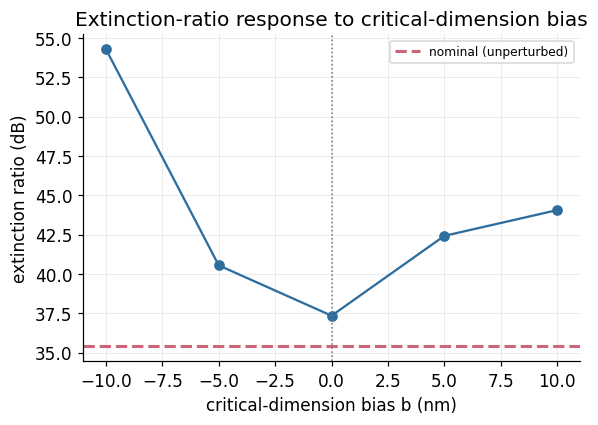

extinction_db across the swept range: min=37.35dB, max=54.28dB, spread=16.93dB (nominal=35.41dB)


In [11]:
bias_vals = np.array([row["bias_nm"] for row in passed_rows])
extinction_vals = np.array([row["extinction_db"] for row in passed_rows])
order = np.argsort(bias_vals)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(bias_vals[order], extinction_vals[order], "o-", color=style.COLOR_STEEL)
ax.axhline(nominal_fringe["extinction_db"], color=style.COLOR_ROSE, lw=2, ls="--",
           label="nominal (unperturbed)")
ax.axvline(0, color=style.COLOR_REFERENCE, lw=1, ls=":")
ax.set_xlabel("critical-dimension bias b (nm)")
ax.set_ylabel("extinction ratio (dB)")
ax.set_title("Extinction-ratio response to critical-dimension bias")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"extinction_db across the swept range: min={extinction_vals.min():.2f}dB, "
      f"max={extinction_vals.max():.2f}dB, spread={extinction_vals.max() - extinction_vals.min():.2f}dB "
      f"(nominal={nominal_fringe['extinction_db']:.2f}dB)")

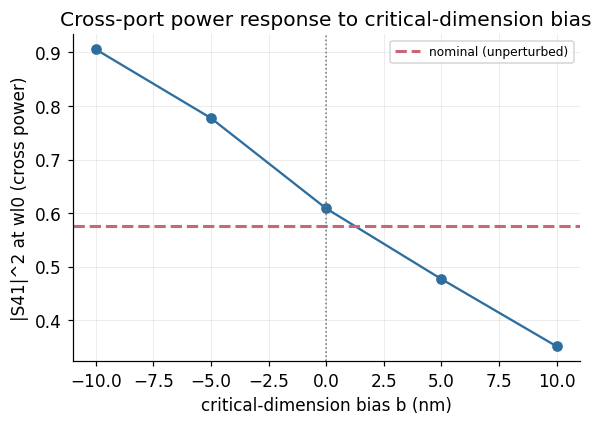

In [12]:
power_vals = np.array([row["power_S41_at_wl0"] for row in passed_rows])

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(bias_vals[order], power_vals[order], "o-", color=style.COLOR_STEEL)
ax.axhline(nominal_power_S41, color=style.COLOR_ROSE, lw=2, ls="--", label="nominal (unperturbed)")
ax.axvline(0, color=style.COLOR_REFERENCE, lw=1, ls=":")
ax.set_xlabel("critical-dimension bias b (nm)")
ax.set_ylabel("|S41|^2 at wl0 (cross power)")
ax.set_title("Cross-port power response to critical-dimension bias")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Interpretation

`data/sparams/mzi/tolerance/manifest.csv` and `tolerance_summary.json`
hold the full per-point and summary data for anything not covered by the
plots above. Every saved point is a **composed** result (standalone coupler
FDTD + calibrated arm phase, wired through `sax.circuit()`, see Section
1/3), not an independent full-MZI FDTD run -- its own metadata records this
explicitly (`method: "sax_circuit_coupler_fdtd_plus_calibrated_arm_phase"`).

**Why the b=0 sweep point doesn't sit exactly on the nominal line.** The
"nominal (unperturbed)" reference in the plots above and the sweep's own
`b=0` point are computed two different ways -- a real, single full-MZI
FDTD simulation vs. a composed (coupler FDTD + calibrated arm-phase)
reconstruction -- and previously also differed in FDTD grid resolution
(the cached production design point is resolution=40; this sweep needed
resolution=50, per the coupler's resolution-convergence study). Section 2 now
regenerates its own resolution=50 copy of the nominal result specifically
to remove that resolution mismatch, so the two now differ only by the
composed-model's own calibration residual (Section 3's `mean_abs_err`,
saved alongside `CALIBRATION_A`/`CALIBRATION_B` in
`data/sparams/mzi/tolerance/calibration_check.json`) -- a real, expected,
and now-quantified approximation error from reconstructing the full device
out of two independently-characterized pieces, not a bug.

`models/waveguide.py`'s own reference-arm model (used by
`wdm_sax.ipynb`/`wdm_mux4_sax.ipynb`) has since received an MPB-measured
group-index correction of the same kind this notebook adds for its own arm.

In [13]:
summary_path = TOLERANCE_DIR / "tolerance_summary.json"
summary_path.write_text(json.dumps({
    "component": "mzi",
    "study": "fabrication_tolerance",
    "method": "sax_circuit_coupler_fdtd_plus_calibrated_arm_phase",
    "nominal_design_point": "data/design_points/mzi.yaml",
    "bias_tol_um": BIAS_TOL_UM,
    "correlation_model": "single_cd_bias_anti_correlated_width_gap",
    "sampling": "deterministic_step_sweep", "bias_step_nm": BIAS_STEP_NM, "n_points": N_SAMPLES,
    "resolution": RESOLUTION_FOR_SWEEP,
    "calibration_a": CALIBRATION_A, "calibration_b": CALIBRATION_B,
    "n_passed": len(passed_rows),
    "summary_statistics": summary,
    "nominal": {**nominal_fringe, "power_S31_at_wl0": nominal_power_S31, "power_S41_at_wl0": nominal_power_S41},
}, indent=2))
print(f"Saved summary: {summary_path}")

Saved summary: ../data/sparams/mzi/tolerance/tolerance_summary.json
